# Regression and Classification Workshop Lab Notebook

**Description:**  
This notebook guides you through hands-on exercises on regression and classification models, including data loading, visualization, model implementation (from scratch and with libraries), and evaluation metrics.

---

## 1 Setup

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

---

## 2 Linear Regression

### 2.1 Data Loading & Preview

In [3]:
df_lr = pd.read_csv('Data/Advertising.csv')  # Our dataset for linear regression
df_lr_single = df_lr[['TV', 'Sales']]  # Single feature for linear regression
df_lr_single.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


### 2.2 Visualize Data

Text(0.5, 1.0, 'Linear Regression Data')

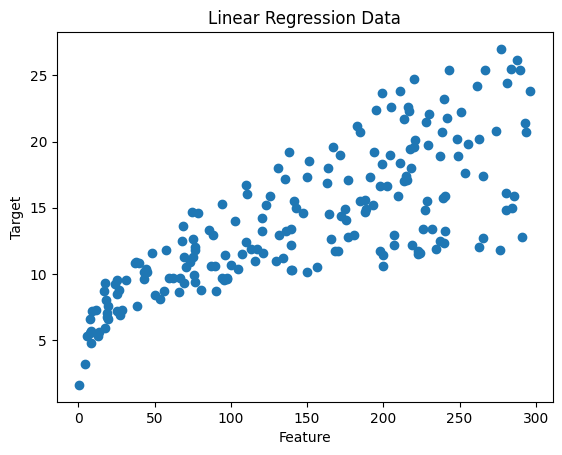

In [4]:
X_lr = df_lr_single[['TV']].values
y_lr = df_lr_single['Sales'].values
plt.scatter(X_lr, y_lr)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression Data')

### 2.3 From-Scratch Gradient Descent (Animated Fit)

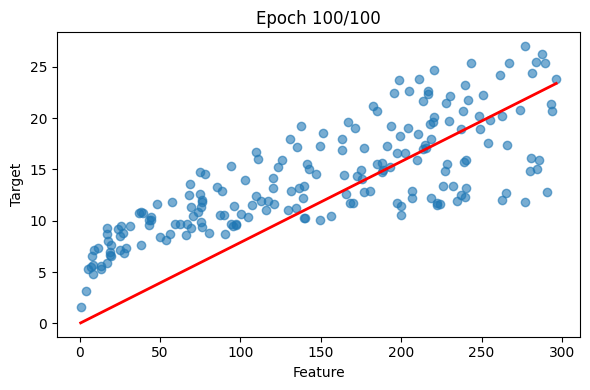

In [5]:
import time
from IPython.display import clear_output

w, b = 0,0
lr = 0.0000005
epochs = 100

for epoch in range(epochs):
    # 1) gradient step
    y_pred = w * X_lr.flatten() + b
    der_w = (-2/len(X_lr)) * np.sum(X_lr.flatten() * (y_lr - y_pred))
    der_b = (-2/len(X_lr)) * np.sum(y_lr - y_pred)
    w -= lr * der_w
    b -= lr * der_b

    # 2) animation update
    clear_output(wait=True)        # clear previous frame
    plt.figure(figsize=(6,4))      # optional: control size
    plt.scatter(X_lr, y_lr, alpha=0.6)
    
    # create a smooth line
    x_line = np.linspace(X_lr.min(), X_lr.max(), 100)
    y_line = w * x_line + b
    plt.plot(x_line, y_line, color='red', linewidth=2)
    
    plt.title(f'Epoch {epoch+1}/{epochs}')
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.tight_layout()
    plt.show()                     # actually render it
    time.sleep(0.1)                # pause so you can see the updatezx  

### 2.4 Library Implementation

Coef: [0.04753664] Intercept: 7.032593549127695


Text(0.5, 1.0, 'Sklearn LinearRegression Fit')

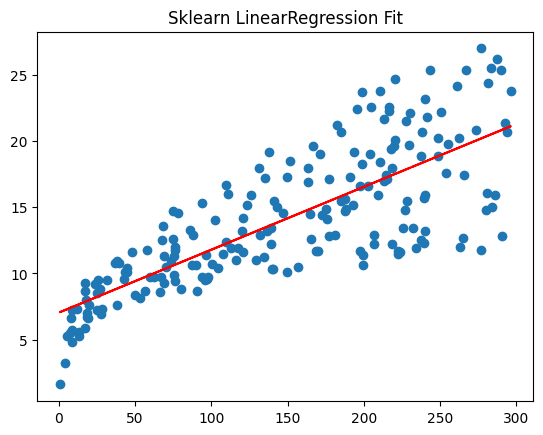

In [6]:
model_lr = LinearRegression()
model_lr.fit(X_lr, y_lr)
print('Coef:', model_lr.coef_, 'Intercept:', model_lr.intercept_)
plt.scatter(X_lr, y_lr)
plt.plot(X_lr, model_lr.predict(X_lr), color='red')
plt.title('Sklearn LinearRegression Fit')

---

## 3 Multivariable Linear Regression

Weights: [0.01933719 0.06008125 0.05746687 0.04078834]
Bias: 0.0011025798178238577


Text(0.5, 1.0, 'Multivariable Regression (Scratch—w vector & b scalar)')

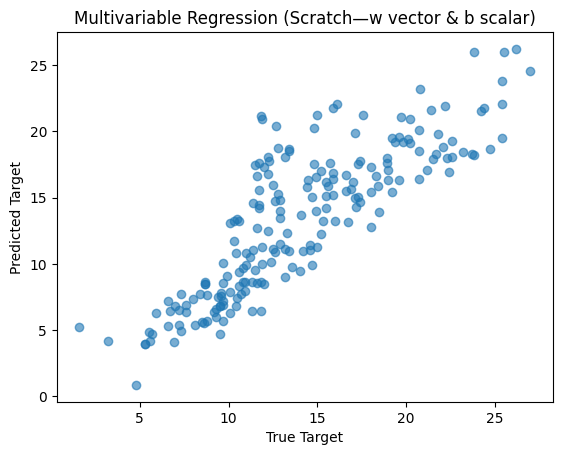

In [7]:
df_mv = pd.read_csv('Data/Advertising.csv')
df_mv.head()

X_mv = df_mv.drop(columns=['Sales']).values
y_mv = df_mv['Sales'].values.flatten()
n, m = X_mv.shape

w = np.zeros(m)  # weight vector (m × 1)
b = 0.0               # bias scalar

lr = 0.000001            # learning rate
iterations = 1000

# Gradient descent loop
for i in range(iterations):
    y_pred = X_mv.dot(w) + b                  # (n_samples,1)
    error = y_pred - y_mv                     # (n_samples,1)
    grad_w = (1/n) * X_mv.T.dot(error)        # (m × 1)
    grad_b = (1/n) * np.sum(error)            # scalar
    w -= lr * grad_w
    b -= lr * grad_b

print('Weights:', w)
print('Bias:', b)

# Predictions and plot
y_pred_mv = X_mv.dot(w) + b
plt.scatter(y_mv, y_pred_mv, alpha=0.6)
plt.xlabel('True Target')
plt.ylabel('Predicted Target')
plt.title('Multivariable Regression (Scratch—w vector & b scalar)')

Coefs: [-0.00057983  0.04577592  0.18838318 -0.00124333]


Text(0.5, 1.0, 'Multivariable Regression')

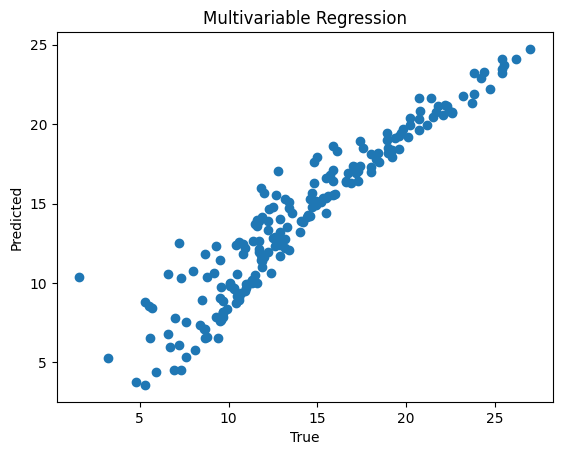

In [8]:

mv_model = LinearRegression().fit(X_mv, y_mv)


print('Coefs:', mv_model.coef_)
y_pred = mv_model.predict(X_mv)
plt.scatter(y_mv, y_pred)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Multivariable Regression')

---

## 4 Polynomial Regression

### 4.1 Degree-2 from Scratch

w1 = 2.1491, w2 = 3.0621, b = 2.3935


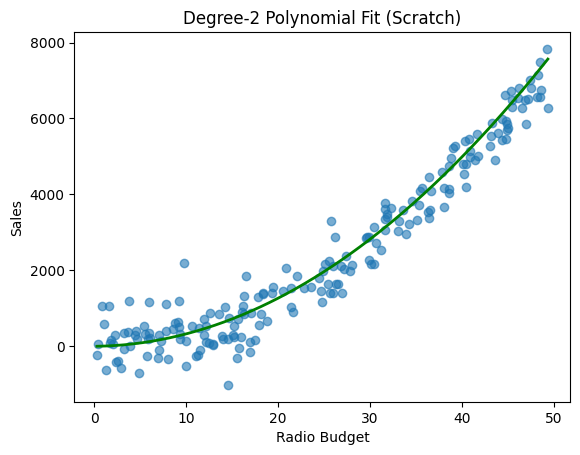

In [9]:
# Simulate polynomial data
np.random.seed(42)
X_poly = np.random.rand(200) * 50  # Random values between 0 and 50
y_poly = 3 * (X_poly ** 2) - 2 * X_poly + 5 + np.random.randn(200) * 500  # Quadratic relationship with increased noise

#Normalization
μ, σ = X_poly.mean(), X_poly.std()
Xn = (X_poly - μ) / σ   


# 2) model function
def poly2_model(x, w1, w2, b):
    """Degree-2 polynomial: ŷ = b + w1·x + w2·x²"""
    return b + w1*x + w2*(x**2)

# 3) init parameters
w1, w2, b = 0.0, 0.0, 0.0
lr = 1e-7
epochs = 5000
n = len(X_poly)

# 4) training loop
for epoch in range(epochs):
    y_pred = poly2_model(Xn, w1, w2, b)     # (n,)
    error  = y_pred - y_poly                    # (n,)

    # gradients
    grad_w1 = (2/n) * np.sum( Xn      * error )   # scalar
    grad_w2 = (2/n) * np.sum((Xn**2)  * error )   # scalar
    grad_b  = (2/n) * np.sum( error )                 # scalar

    # parameter updates
    w1 -= lr * grad_w1
    w2 -= lr * grad_w2
    b  -= lr * grad_b

# 5) results
print(f"w1 = {w1:.4f}, w2 = {w2:.4f}, b = {b:.4f}")

# 6) plot fit
plt.scatter(X_poly, y_poly, alpha=0.6)
x_line = np.linspace(X_poly.min(), X_poly.max(), 200)
y_line = poly2_model(x_line, w1, w2, b)
plt.plot(x_line, y_line, color='green', linewidth=2)
plt.title('Degree-2 Polynomial Fit (Scratch)')
plt.xlabel('Radio Budget')
plt.ylabel('Sales')
plt.show()

### 4.2 General Polynomial via Libraries

Text(0.5, 1.0, 'Sklearn PolynomialFeatures Fit (Degree 3)')

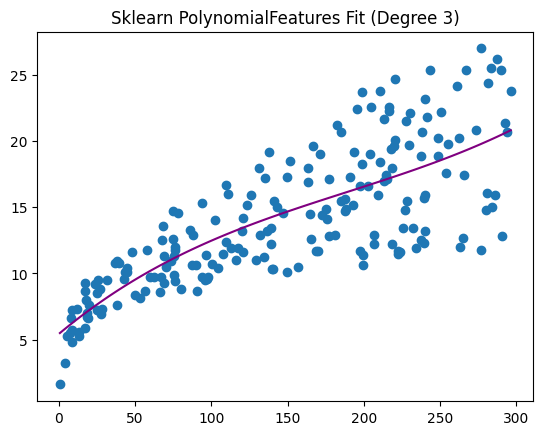

In [10]:

pf = PolynomialFeatures(degree=3)
Xp = pf.fit_transform(X_lr)
poly_model = LinearRegression().fit(Xp, y_lr)
x_line = np.linspace(X_lr.min(), X_lr.max(), 100).reshape(-1,1)
xp_line = pf.transform(x_line)
plt.scatter(X_lr, y_lr)
plt.plot(x_line, poly_model.predict(xp_line), color='purple')
plt.title('Sklearn PolynomialFeatures Fit (Degree 3)')

---

## 5 Classification

### 5.1 Binary Classification from Scratch

In [11]:
# 1) Load data & set up
df_bin = pd.read_csv('Data/Social_Network.csv')
feature_cols = [
    'Age',
    'EstimatedSalary'
]
Xb = df_bin[feature_cols].values        # shape (n_samples, 2)
yb = df_bin['Purchased'].values     # shape (n_samples,)

scaler = StandardScaler().fit(Xb)
Xb = scaler.transform(Xb)

# 2) Sigmoid helper
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3) Initialize parameters
w = np.zeros(Xb.shape[1])  # (8,)
b = 0.0
lr = 0.02
iterations = 5000
n = len(yb)

# 4) Gradient descent loop
for _ in range(iterations):
    z     = Xb.dot(w) + b          # (n,)
    pred  = sigmoid(z)             # (n,)
    error = pred - yb              # (n,)

    grad_w = (1/n) * Xb.T.dot(error)  # (8,)
    grad_b = np.mean(error)           # scalar

    w -= lr * grad_w
    b -= lr * grad_b

print("Trained weights:", w)
print("Trained bias:", b)


Trained weights: [2.3784964  1.19045523]
Trained bias: -1.112592540565505


#### Decision Boundary

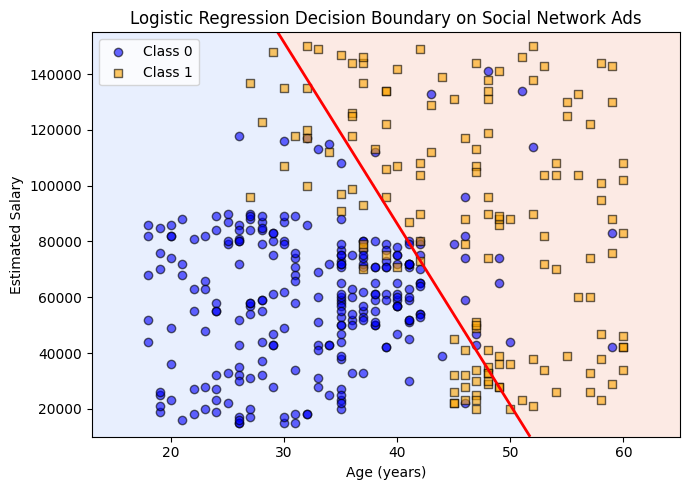

In [ ]:
import matplotlib.pyplot as plt

# 1) Unpack scaler parameters for inversion
mu, sigma = scaler.mean_, scaler.scale_

# 2) Define feature indices
f1, f2 = 0, 1  # Age, EstimatedSalary

# 3) Create a grid in the ORIGINAL feature space
pad1, pad2 = 5, 5000  # a little extra margin
age_min, age_max = df_bin['Age'].min() - pad1, df_bin['Age'].max() + pad1
sal_min, sal_max = df_bin['EstimatedSalary'].min() - pad2, df_bin['EstimatedSalary'].max() + pad2

xx, yy = np.meshgrid(
    np.linspace(age_min, age_max, 200),
    np.linspace(sal_min, sal_max, 200)
)

# 4) Build the grid array and scale it
grid_orig = np.c_[xx.ravel(), yy.ravel()]       # shape (40000, 2)
grid_scaled = (grid_orig - mu) / sigma          # standardize each column

# 5) Compute model probability on the scaled grid
zz    = grid_scaled.dot(w) + b
probs = sigmoid(zz).reshape(xx.shape)

# 6) Plot
plt.figure(figsize=(7,5))

# shading for class=1
plt.contourf(xx, yy, probs > 0.5, alpha=0.2, cmap='coolwarm')

# 0.5 decision boundary
plt.contour(xx, yy, probs, levels=[0.5], colors='red', linewidths=2)

# scatter original points
plt.scatter(
    df_bin.loc[yb==0, 'Age'],
    df_bin.loc[yb==0, 'EstimatedSalary'],
    c='blue', marker='o', edgecolor='k', alpha=0.6, label='Not Purchased'
)
plt.scatter(
    df_bin.loc[yb==1, 'Age'],
    df_bin.loc[yb==1, 'EstimatedSalary'],
    c='orange', marker='s', edgecolor='k', alpha=0.6, label='Purchased'
)

plt.xlabel('Age (years)')
plt.ylabel('Estimated Salary')
plt.title('Logistic Regression Decision Boundary on Social Network Ads')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### 5.2 Multiclass Classification with Libraries

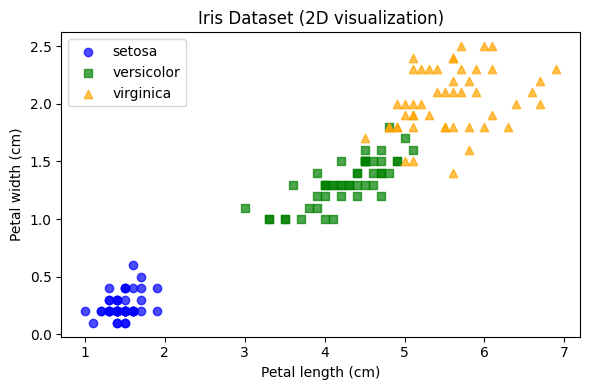

Confusion Matrix:
 [[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]


/home/penguine/DataAnalysisPython/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# ─── Multiclass on a 2D‐visualizable dataset ────────────────────────────────────

# 1) Load & preview a 2-feature slice of Iris
from sklearn.datasets import load_iris

iris = load_iris()
# pick just petal length & petal width so we can plot in 2D
Xm = iris.data[:, 2:4]      # shape (150, 2)
ym = iris.target            # shape (150,)

# 2) Scatter plot by class
plt.figure(figsize=(6,4))
for cls, marker, color in zip([0,1,2], ['o','s','^'], ['blue','green','orange']):
    plt.scatter(
        Xm[ym==cls, 0], Xm[ym==cls, 1],
        marker=marker, color=color, alpha=0.7,
        label=iris.target_names[cls]
    )
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Iris Dataset (2D visualization)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()



/home/penguine/DataAnalysisPython/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


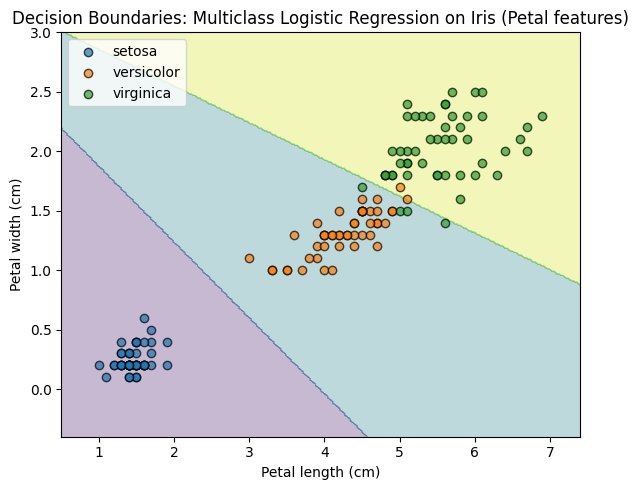

In [15]:
# Scale features
scaler = StandardScaler().fit(Xm)
Xm_s = scaler.transform(Xm)


# Train multinomial logistic regression
mc_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
mc_model.fit(Xm_s, ym)

# Create grid in original feature space
x_min, x_max = Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5
y_min, y_max = Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Scale grid and predict
grid_s = scaler.transform(grid)
Z = mc_model.predict(grid_s).reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Overlay data points
for idx, cls_name in enumerate(iris.target_names):
    plt.scatter(
        Xm[ym == idx, 0], Xm[ym == idx, 1],
        edgecolor='k', label=cls_name, alpha=0.7
    )

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Decision Boundaries: Multiclass Logistic Regression on Iris (Petal features)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

---

## 6 Model Evaluation

### 6.1 Regression Metrics

In [16]:
print('MSE:', mean_squared_error(y_lr, model_lr.predict(X_lr)))
print('RMSE:', np.sqrt(mean_squared_error(y_lr, model_lr.predict(X_lr))))
print('MAE:', mean_absolute_error(y_lr, model_lr.predict(X_lr)))
print('R2:', r2_score(y_lr, model_lr.predict(X_lr)))

MSE: 10.512652915656757
RMSE: 3.2423221486546887
MAE: 2.549806038927486
R2: 0.611875050850071


### 6.2 Classification Metrics

In [18]:
z     = Xb.dot(w) + b          
pred  = sigmoid(z)
yb_pred = (pred >= 0.5).astype(int)  # convert probabilities to binary predictions
print('Accuracy:', accuracy_score(yb, yb_pred))
print('Precision:', precision_score(yb, yb_pred))
print('Recall:', recall_score(yb, yb_pred))
print('F1:', f1_score(yb, yb_pred))
print('Multiclass Accuracy:', accuracy_score(ym, ym_pred))
print('Multiclass Precision (macro):', precision_score(ym, ym_pred, average='macro'))
print('Multiclass Recall (macro):', recall_score(ym, ym_pred, average='macro'))
print('Multiclass F1 (macro):', f1_score(ym, ym_pred, average='macro'))

Accuracy: 0.845
Precision: 0.8292682926829268
Recall: 0.7132867132867133
F1: 0.7669172932330827
Multiclass Accuracy: 0.9533333333333334
Multiclass Precision (macro): 0.9534480458850206
Multiclass Recall (macro): 0.9533333333333333
Multiclass F1 (macro): 0.9533286661999533


---
**Next Steps:**
- Experiment with different learning rates/epochs
- Try regularized regression (Ridge, Lasso)
- Explore tree-based models and advanced metrics

_End of Lab Notebook._